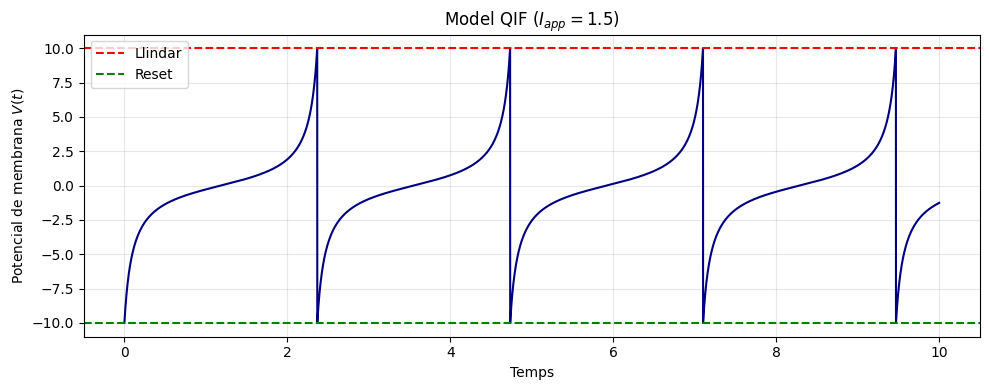

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define Model Parameters
I_app = 1.5     # Applied current (try -1.0 for resting, 1.5 for spiking)
V_th = 10.0        # Spike threshold
V_reset = -10.0    # Reset potential

# 2. Define Simulation Parameters
dt = 0.001         # Time step
T_max = 10.0       # Total simulation time
time = np.arange(0, T_max, dt)
N = len(time)

# 3. Initialize Arrays
V = np.zeros(N)
V[0] = V_reset     # Initial condition

# 4. Euler Integration Loop
for i in range(N - 1):
    # Calculate the derivative
    dVdt = V[i]**2 + I_app
    
    # Forward Euler step
    V[i+1] = V[i] + dVdt * dt
    
    # Check for spike (reset condition)
    if V[i+1] >= V_th:
        V[i+1] = V_reset
        V[i] = V_th # Optional: artificially pin the peak to V_th for cleaner plotting

# 5. Plotting the Results
plt.figure(figsize=(10, 4))
plt.plot(time, V, color='navy', lw=1.5)
plt.axhline(V_th, color='red', linestyle='--', label='Llindar')
plt.axhline(V_reset, color='green', linestyle='--', label='Reset')
plt.title(f'Model QIF ($I_{{app}} = {I_app}$)')
plt.xlabel('Temps')
plt.ylabel('Potencial de membrana $V(t)$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

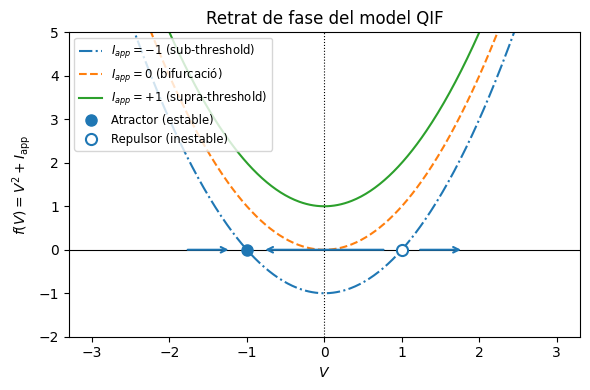

In [3]:
V_vals = np.linspace(-3, 3, 400)
fig, ax = plt.subplots(figsize=(6, 4))

for I, ls, label in [(-1.0, '-.', '$I_{app}=-1$ (sub-threshold)'),
                     ( 0.0, '--', '$I_{app}=0$ (bifurcació)'),
                     ( 1.0, '-',  '$I_{app}=+1$ (supra-threshold)')]:
    ax.plot(V_vals, V_vals**2 + I, ls=ls, label=label)

ax.axhline(0, color='k', lw=0.8)
ax.axvline(0, color='k', lw=0.8, ls=':')

# --- AFEGIR FLETXES DE FLUX SOBRE L'EIX HORITZONTAL (f(V) = 0) ---

# Per a I_app = -1, els equilibris estan a V = -1 i V = 1
# Estil comú per a les fletxes de flux
arrow_props = dict(arrowstyle="->", lw=1.5, color='tab:blue')

# Flux a l'esquerra de V = -1: f(V) > 0 (cap a la dreta)
ax.annotate('', xy=(-1.2, 0), xytext=(-1.8, 0), arrowprops=arrow_props)

# Flux entre V = -1 i V = 1: f(V) < 0 (cap a l'esquerra)
ax.annotate('', xy=(-0.8, 0), xytext=(0.8, 0), arrowprops=dict(arrowstyle="->", lw=1.5, color='tab:blue'))

# Flux a la dreta de V = 1: f(V) > 0 (cap a l'esquerra cap a la dreta)
ax.annotate('', xy=(1.8, 0), xytext=(1.2, 0), arrowprops=arrow_props)


# --- DIBUIXAR ELS PUNTS D'EQUILIBRI ---

# Atractor (estable): cercle ple a V = -1
ax.plot(-1, 0, 'o', color='tab:blue', markersize=8, label='Atractor (estable)')

# Repulsor (inestable): cercle buit a V = 1
ax.plot(1, 0, 'o', markerfacecolor='white', markeredgecolor='tab:blue', markeredgewidth=1.5, markersize=8, label='Repulsor (inestable)')


# --- CONFIGURACIÓ DE L'EIX I LLEGENDES ---
ax.set_xlabel('$V$')
ax.set_ylabel('$f(V) = V^2 + I_{\\rm app}$')
ax.set_title('Retrat de fase del model QIF')

# Fem una llegenda més neta ordenant o simplement mostrant-ho tot
ax.legend(loc='upper left', fontsize='small')
ax.set_ylim(-2, 5)
plt.tight_layout()
plt.show()